In [ ]:
#SOBEL EDGE DETECTOR

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from io import StringIO

IMG_PATH = '../Data/pug.jpg'

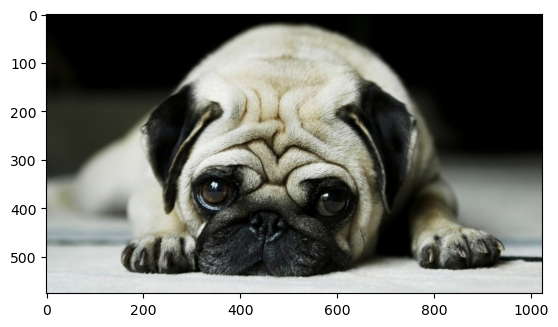

In [2]:
img = mpimg.imread(IMG_PATH)
plt.imshow(img)
plt.show()

In [3]:
# Define: original picture, vertical gradient filter as well as horizontal gradient filter.
orig_img = img
vertical_grad_filter = np.array([[1, 0, -1], [2, 0, -2], [3, 0, -3]])
horizontal_grad_filter = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

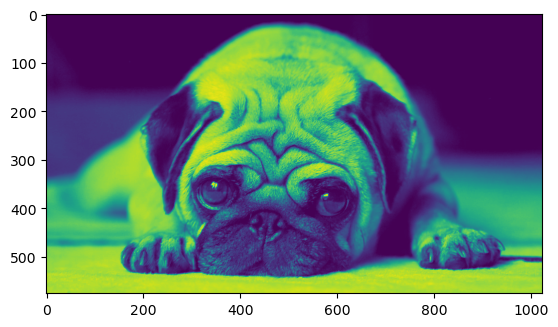

In [4]:
# Convert img to grayscale
img = np.dot(img, [1, 1, 1])//3
img = img/255

plt.imshow(img)
plt.show()

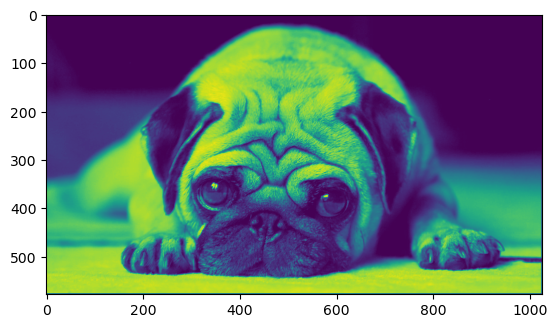

In [6]:
kernal_width = vertical_grad_filter.shape[0]//2
grad_map = np.zeros(img.shape)
img = np.pad(img, pad_width=([kernal_width, ], [kernal_width]), 
                            mode='constant', constant_values=(0, 0))

plt.imshow(img)
plt.show()

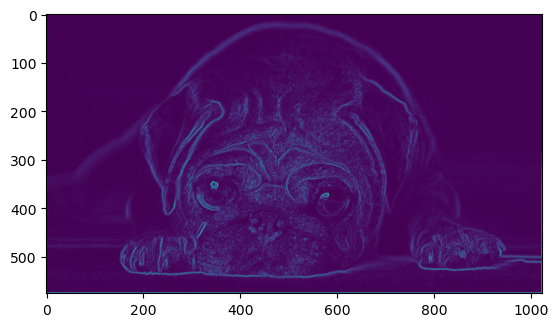

In [7]:
for i in range(kernal_width, img.shape[0] - kernal_width):
    for j in range(kernal_width, img.shape[1] - kernal_width):
        # Get a kernal.
        kernal = img[i - kernal_width : i+kernal_width+1, j - kernal_width : j + kernal_width + 1]
        # Implement x and y after getting the kernal.
        x = kernal.flatten()*vertical_grad_filter.flatten()
        sum_x = x.sum()

        y = kernal.flatten()*horizontal_grad_filter.flatten()
        sum_y = y.sum()

        grad_map[i-kernal_width][j-kernal_width] = np.sqrt(sum_x**2 + sum_y**2)

img = grad_map

plt.imshow(img)
plt.show()